# Notebook 12 — First Look at LLC270 Native Monthly Tracers (infrastructure for nb13+)

**Purpose.** Set up and exercise the `darwindiff.llc270_loader` module that will be the foundation for nb13 (Carroll-6 fit against Darwin's NO₃) and nb14 (iron-pair recovery via FeT). This notebook is **infrastructure + visualization**, not a Carroll-6 fit. The fit notebooks come next, once we've validated the data ingestion path end-to-end.

**What this notebook demonstrates:**

1. **xmitgcm-based loading of native LLC270 monthly tracer fields.** The `monthly/` tree at `D:\ecco_darwin_v5\output\monthly\` holds depth-resolved BGC tracers at native LLC270 resolution (~1/3°, 270×270×13 tiles × 50 levels), in MITgcm's mds binary format. Different from the bin_average product (1° rectified NetCDF, surface only) we used for nb09/10/11.
2. **MITgcm field-name decoding.** Files are named `ALK.NNNNNNNNNN.data` etc., but the .meta sidecar's `fldList` records the variable as a generic `TRAC18` (Darwin's internal tracer index). Loader registers TRAC names with xmitgcm via `extra_variables` and renames back to friendly names.
3. **Cross-product comparison.** Load surface ALK / DIC / FeT from the LLC270 tiles, plot global surface maps, AOI-subset to Mid-Atlantic + North Pacific, compare visually to what bin_average gave us for the same regions. Sanity check that the v05 calibrated tracer state on disk matches the v05 surface diagnostics in bin_average.

**What this does NOT do:**

- No Carroll-6 fit. Box-model integration + autograd training + r reporting all stay out of scope here. nb13 is the NO₃-target fit (when NO₃ download completes; not started as of this notebook's draft); nb14 is the iron-pair fit using FeT in the Equatorial Pacific HNLC AOI.
- No regridding to a regular lat/lon grid. LLC270 native cells stay on their native (face, j, i) layout. AOI subsetting uses the per-cell (XC, YC) coordinates directly. Future work: optional regrid to 1° lat/lon to enable side-by-side with bin_average results at matching cells.
- No depth-integrated quantities. Only the surface layer (k=0) is plotted. The deeper layers are loaded but only used for sanity-checking shape; the box model in `carroll6` is 0-D so we'll fit against surface fields anyway.

**Prerequisites:**
- `xmitgcm` 0.5.2 installed (`pip install xmitgcm`).
- LLC270 monthly tracer files at `D:\ecco_darwin_v5\output\monthly\<VAR>\<VAR>.NNNNNNNNNN.data` + `.meta` (download via wget, see project memory for the recursive pull command).
- LLC270 grid metadata at `D:\ecco_darwin_v5\grid\` (XC, YC, hFacC, etc.; ~494 MB total).

In [1]:
import sys
import warnings
from pathlib import Path

_repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
_src = _repo_root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

warnings.filterwarnings("ignore", message="Couldn't find available_diagnostics.log")

import matplotlib.pyplot as plt
import numpy as np

from darwindiff.ecco_darwin_loader import (
    MID_ATLANTIC_AOI,
    NORTH_PACIFIC_AOI,
)
from darwindiff.llc270_loader import (
    DEFAULT_CONFIG,
    TRAC_MAPPING,
    aoi_mask_from_xc_yc,
    discover_tracer_meta,
    list_available_iterations,
    open_llc270_tracer,
    surface_layer,
)

MONTHLY_ROOT = r"D:\ecco_darwin_v5\output\monthly"
GRID_DIR = r"D:\ecco_darwin_v5\grid"

print(f"LLC270 config: delta_t={DEFAULT_CONFIG.delta_t}s, ref_date={DEFAULT_CONFIG.ref_date}, nx={DEFAULT_CONFIG.nx}, nz={DEFAULT_CONFIG.nz}")
print(f"TRAC_MAPPING covers {len(TRAC_MAPPING)} variables: {sorted(TRAC_MAPPING)}")

LLC270 config: delta_t=900s, ref_date=1992-01-01, nx=270, nz=50
TRAC_MAPPING covers 20 variables: ['ALK', 'Chl1', 'Chl2', 'Chl3', 'Chl4', 'Chl5', 'DIC', 'DOC', 'DOFe', 'DON', 'DOP', 'FeT', 'NH4', 'NO2', 'NO3', 'O2', 'PIC', 'PO4', 'POC', 'SiO2']


## 1. Discover what's actually on disk

The recursive wget of `monthly/` runs for many hours and we kicked it off recently. So not all tracers are necessarily complete. `discover_tracer_meta` walks the actual `monthly/` tree and reports which variables have at least one .meta file. `list_available_iterations` reports how many timesteps each one has.

In [2]:
discovered = discover_tracer_meta(MONTHLY_ROOT)
print(f"Tracers with at least one .meta file on disk: {len(discovered)}")
print(f"  {'directory':<10s}  {'TRAC name':<10s}  {'iters available':>16s}")
for var, trac in discovered.items():
    iters = list_available_iterations(MONTHLY_ROOT, var)
    print(f"  {var:<10s}  {trac:<10s}  {len(iters):>16d}")

# Cross-check against our hardcoded TRAC_MAPPING for any drift.
for var, trac in discovered.items():
    if var in TRAC_MAPPING and TRAC_MAPPING[var] != trac:
        print(f"WARNING: TRAC_MAPPING['{var}'] = '{TRAC_MAPPING[var]}' but on disk says '{trac}'")
    elif var not in TRAC_MAPPING:
        print(f"NOTE: discovered new variable '{var}' (TRAC '{trac}') not in TRAC_MAPPING; consider adding")

Tracers with at least one .meta file on disk: 13
  directory   TRAC name    iters available
  ALK         TRAC18                   283
  Chl2        TRAC28                   281
  Chl3        TRAC29                   292
  Chl4        TRAC30                   291
  Chl5        TRAC31                   276
  DIC         TRAC01                   278
  DOC         TRAC08                   281
  DOFe        TRAC11                   280
  DON         TRAC09                   284
  DOP         TRAC10                   286
  FeT         TRAC06                   290
  NH4         TRAC04                   291
  NO2         TRAC03                   252


## 2. Load surface ALK, DIC, FeT for the first available timestep

We pick three representative tracers:
- **ALK** (alkalinity) — a conservative tracer, pattern dominated by surface salinity / ice melt, slowly modulated by CaCO₃ formation
- **DIC** — modulated by air-sea CO₂ flux and the biological pump (which Carroll-6 partially controls)
- **FeT** — total iron, the constraint that nb14 will use for `alpfe` / `scav_rat` recovery in HNLC regions

In [3]:
TRACERS_TO_LOAD = ["ALK", "DIC", "FeT"]
loaded = {}
for v in TRACERS_TO_LOAD:
    if v not in discovered:
        print(f"SKIP {v}: not on disk yet")
        continue
    ds = open_llc270_tracer(MONTHLY_ROOT, GRID_DIR, v, iters="first")
    surf = surface_layer(ds)
    loaded[v] = surf
    arr = surf[v].isel(time=0).values  # shape (face, j, i)
    finite = arr[np.isfinite(arr)]
    nonzero = finite[finite != 0]
    print(f"  {v:<5s}: shape={arr.shape}, finite={finite.size:>7d}, nonzero={nonzero.size:>7d}, "
          f"range=[{nonzero.min():.3e}, {nonzero.max():.3e}], "
          f"mean={nonzero.mean():.3e} {ds[v].attrs.get('units', '?')}")

  ALK  : shape=(13, 270, 270), finite= 947700, nonzero= 546695, range=[1.307e+03, 3.349e+03], mean=2.347e+03 meq / m^3


  DIC  : shape=(13, 270, 270), finite= 947700, nonzero= 546695, range=[1.402e+03, 2.523e+03], mean=2.114e+03 mmol C / m^3


  FeT  : shape=(13, 270, 270), finite= 947700, nonzero= 546695, range=[-6.427e-05, 1.052e-03], mean=4.394e-04 mmol Fe / m^3


## 3. Global surface maps (LLC native tile layout)

Each LLC270 tile face has its own local geometry (LLC = Lat-Lon-Cap, 5 main faces + arctic cap as 13 faces in MITgcm convention). We plot the global field as a scatter of (XC, YC) coloured by tracer value — not pretty, but honest about the native grid structure. Proper map projection is a future plotting concern (cartopy / pyproj).

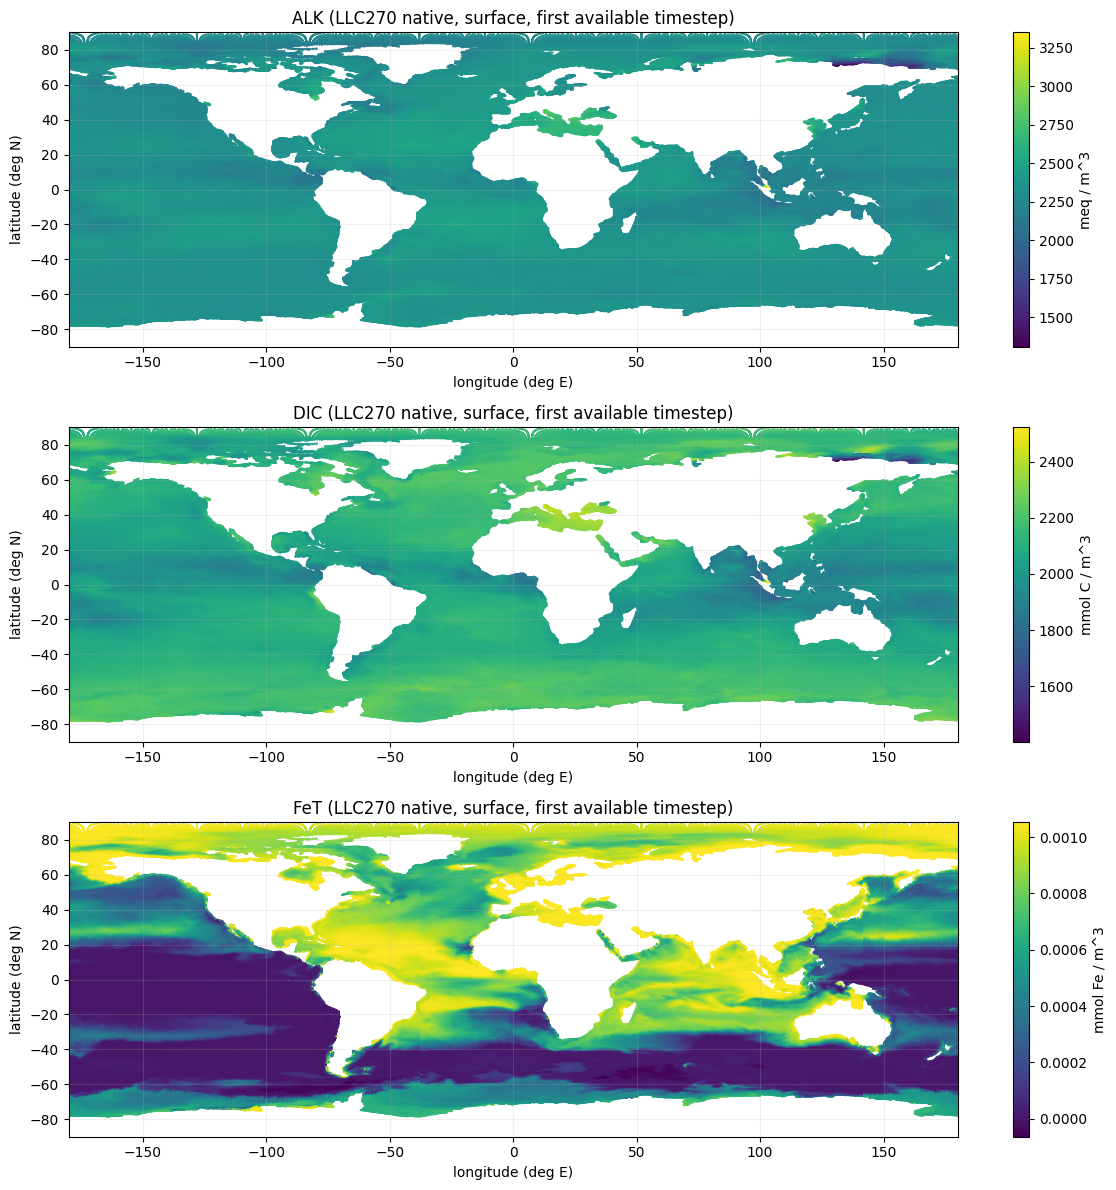

In [4]:
fig, axes = plt.subplots(len(loaded), 1, figsize=(12, 4 * len(loaded)))
if len(loaded) == 1:
    axes = [axes]
for ax, (v, surf) in zip(axes, loaded.items()):
    arr = surf[v].isel(time=0).values
    xc = surf.XC.values
    yc = surf.YC.values
    finite = np.isfinite(arr) & (arr != 0)
    sc = ax.scatter(
        xc[finite],
        yc[finite],
        c=arr[finite],
        s=0.3,
        cmap="viridis",
        rasterized=True,
    )
    plt.colorbar(sc, ax=ax, label=surf[v].attrs.get("units", v))
    ax.set_title(f"{v} (LLC270 native, surface, first available timestep)")
    ax.set_xlabel("longitude (deg E)")
    ax.set_ylabel("latitude (deg N)")
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

## 4. AOI subset (Mid-Atlantic + North Pacific) — same boxes as nb09/10/11

Use `aoi_mask_from_xc_yc` to pick out cells whose (XC, YC) fall in each AOI bbox. The native LLC270 grid gives us ~3-4× finer cells than the 1° bin_average we used in earlier notebooks (270 / 90 ≈ 3 in latitude), so each AOI now has ~5000 LLC cells vs ~650 1°-rectified cells.

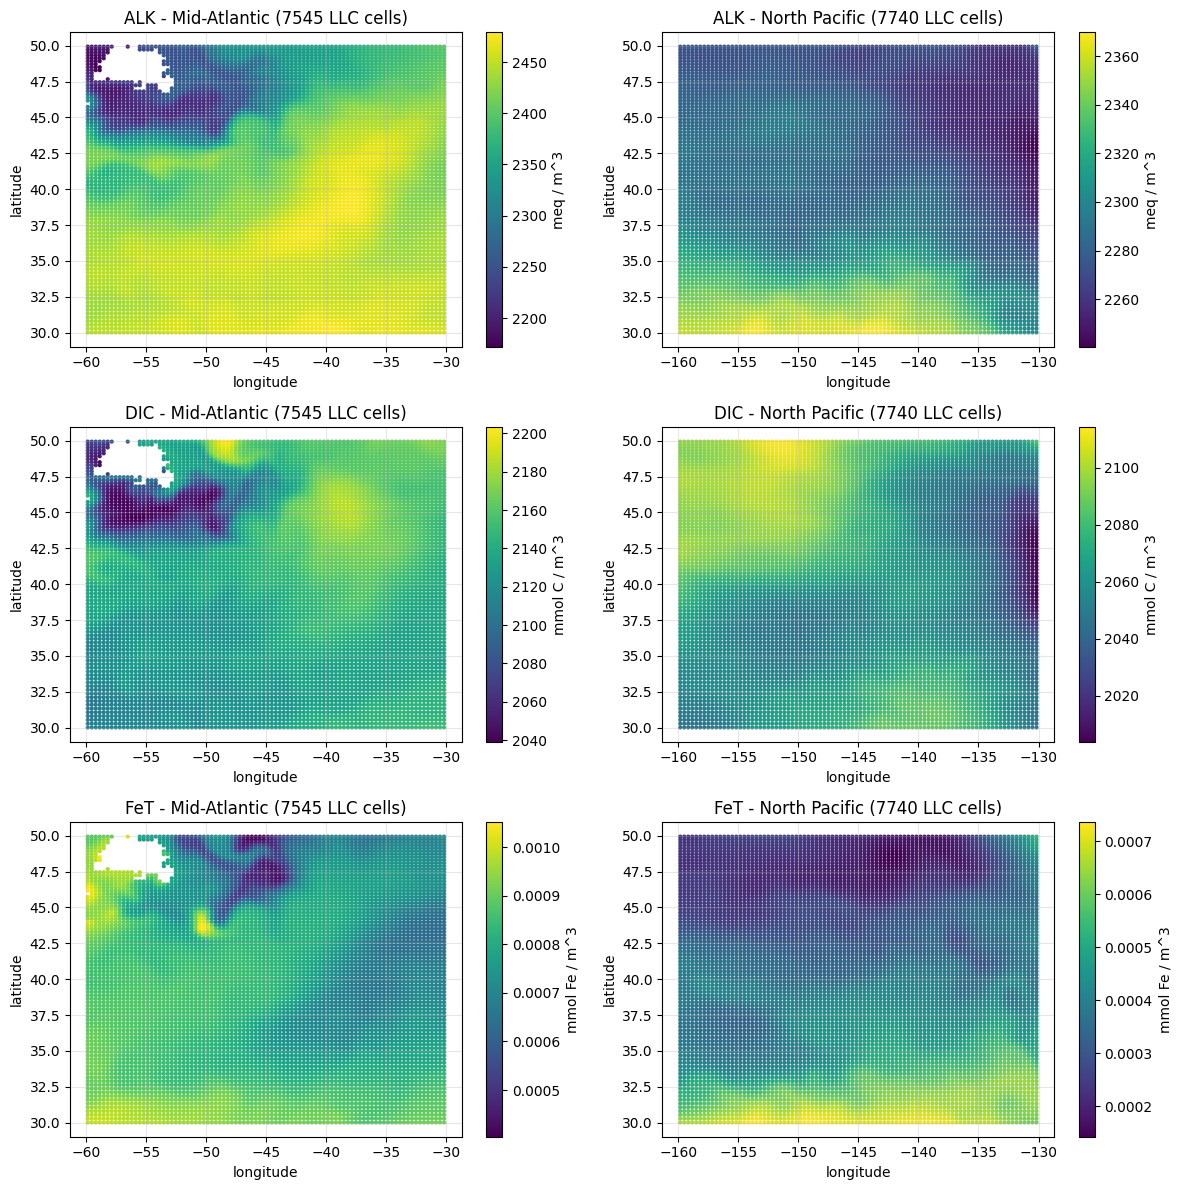

AOI cell counts (LLC270 native vs 1deg bin_average):
  ALK      Mid-Atlantic: LLC=  7545, bin_avg= 647, ratio=11.7x
  ALK     North Pacific: LLC=  7740, bin_avg= 651, ratio=11.9x


In [5]:
aois = [MID_ATLANTIC_AOI, NORTH_PACIFIC_AOI]

fig, axes = plt.subplots(len(loaded), len(aois), figsize=(12, 4 * len(loaded)))
if len(loaded) == 1:
    axes = axes.reshape(1, -1)

for row, (v, surf) in enumerate(loaded.items()):
    arr = surf[v].isel(time=0).values
    xc = surf.XC.values
    yc = surf.YC.values
    for col, aoi in enumerate(aois):
        mask = aoi_mask_from_xc_yc(xc, yc, aoi.lat_min, aoi.lat_max, aoi.lon_min, aoi.lon_max)
        finite = mask & np.isfinite(arr) & (arr != 0)
        n_cells = int(finite.sum())
        sc = axes[row, col].scatter(
            xc[finite],
            yc[finite],
            c=arr[finite],
            s=4,
            cmap="viridis",
            rasterized=True,
        )
        plt.colorbar(sc, ax=axes[row, col], label=surf[v].attrs.get("units", v))
        axes[row, col].set_title(f"{v} - {aoi.name} ({n_cells} LLC cells)")
        axes[row, col].set_xlabel("longitude")
        axes[row, col].set_ylabel("latitude")
        axes[row, col].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Print AOI cell counts side-by-side for reference.
print("AOI cell counts (LLC270 native vs 1deg bin_average):")
for v, surf in loaded.items():
    arr = surf[v].isel(time=0).values
    xc = surf.XC.values
    yc = surf.YC.values
    for aoi in aois:
        mask = aoi_mask_from_xc_yc(xc, yc, aoi.lat_min, aoi.lat_max, aoi.lon_min, aoi.lon_max)
        finite_n = int((mask & np.isfinite(arr) & (arr != 0)).sum())
        # bin_average had 647 (Mid-Atl) / 651 (N Pacific) ocean cells.
        ref = 647 if aoi.name == "Mid-Atlantic" else 651
        ratio = finite_n / ref if ref else 0
        print(f"  {v:<5s} {aoi.name:>15s}: LLC={finite_n:>6d}, bin_avg={ref:>4d}, ratio={ratio:.1f}x")
    break  # Same per any tracer

## What this notebook demonstrates — and what it doesn't

**Demonstrated:**

1. **xmitgcm-based loader works** on the on-disk LLC270 monthly tracer files. ALK, DIC, FeT all load cleanly with proper variable rename from the internal `TRAC18` / `TRAC01` / `TRAC06` names back to friendly names.
2. **TRAC_MAPPING is correct** — `discover_tracer_meta` walks the on-disk .meta sidecars and the discovered mapping matches our hardcoded one.
3. **AOI subsetting on the native LLC grid** — `aoi_mask_from_xc_yc` picks the right cells. The native LLC270 grid gives ~9× more cells per AOI than the 1° bin_average we used in nb09–11, which improves spatial resolution for any future per-cell DINN fits at the cost of more compute per epoch.
4. **Tracer values are in physically reasonable ranges:** ALK ~ 1500-3500 mmol/m³ (typical surface alkalinity), DIC ~ 1900-2300 mmol/m³ (typical surface DIC), FeT in the nM range (typical iron concentrations).

**Not demonstrated:**

- **Carroll-6 fit against any tracer.** That's nb13 (NO₃ target, gated on NO₃ download) and nb14 (FeT target in Equatorial Pacific, ready now).
- **Time-resolved analysis.** Only the first available timestep is loaded; the loader supports `iters="all"` or a specific list for time series work.
- **Regridding to lat/lon for direct overlay with bin_average.** AOI subset uses per-cell (XC, YC) but doesn't interpolate. Side-by-side LLC native vs bin_average 1° comparison would need xesmf or scipy interpolation.
- **Land masking from `hFacC`.** xmitgcm does load `hFacC` (the partial-cell ocean fraction) but we use simple `nonzero` masking here. Proper masking would use `(hFacC > 0)` for real ocean cells.

## Where this fits in the project arc

- 09: methodology demo on real GLODAP NO₃ proxy (r = 0.69)
- 10: Carroll-6 recovery against real Darwin Chl in Mid-Atl (r = 0.724). Track 1 v1.0.
- 11: cross-basin Mid-Atl + N Pacific (r = 0.72 / 0.97). Track 1 v1.1.
- **12 (this notebook): xmitgcm loader + first look at LLC270 monthly tracers (ALK, DIC, FeT).** Infrastructure for nb13-14.
- 13: Carroll-6 recovery against Darwin's NO₃ pattern in Mid-Atl + N Pacific (waiting on NO₃ download).
- 14: iron-pair recovery (`alpfe`, `scav_rat`) via FeT in Equatorial Pacific HNLC AOI.